# Signal & Performance Visualizations (Light Theme)

This notebook generates high-fidelity, presentation-ready visualizations in a custom light theme with `#fff4ea` background. It covers:
1. **Battery Voltage Channel (Time-Domain):** Showing the progressive voltage sag under load and large oscillations in a degrading pack compared to a stable healthy pack.
2. **Vibration Channel (Frequency-Domain):** Illustrating the frequency-domain spectral signature comparing healthy vs bearing fault conditions.
3. **Pipeline Results & Comparisons:** Visualizing the baseline modality performance, and comparing Stage 3 (Fusion) vs Stage 4 (Multitask).

In [28]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.data import load_split
from src.features_signal import _impute_dropout

# Set light mode style with #fff4ea background
plt.rcParams.update({
    'figure.facecolor': '#fff4ea',
    'axes.facecolor': '#fff4ea',
    'axes.edgecolor': '#e1d8cd',
    'axes.labelcolor': '#24292f',
    'xtick.color': '#57606a',
    'ytick.color': '#57606a',
    'text.color': '#24292f',
    'grid.color': '#e1d8cd',
    'grid.linestyle': '-',
    'grid.alpha': 0.6,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

## 1. Load Data Splits

In [29]:
train = load_split('train')
tab = train['tab']
signals = train['signals']
channel_names = train['channel_names']

print('Tabular columns:', list(tab.columns))
print('Signal channels:', list(channel_names))

Tabular columns: ['flight_id', 'drone_id', 'model', 'motor_type', 'firmware_version', 'battery_capacity_mAh', 'max_payload_g', 'propeller_in', 'manufacture_batch', 'operator_region', 'flight_index', 'payload_g', 'ambient_temp_C', 'wind_speed_ms', 'flight_duration_min', 'avg_throttle', 'num_aggressive_maneuvers', 'cumulative_flight_hours', 'battery_cycles', 'failure_mode', 'failure_within_horizon']
Signal channels: [np.str_('accel_x'), np.str_('accel_y'), np.str_('accel_z'), np.str_('gyro_z'), np.str_('motor_current_1'), np.str_('motor_current_2'), np.str_('vibration'), np.str_('battery_voltage')]


## 2. Class Distribution (Target Imbalance)
We inspect the class distribution of `failure_within_horizon` in the training split. The class balance is heavily imbalanced (~12.5% positive rate), which dictates the choice of **Average Precision (AUPRC)** as the primary evaluation metric. A naive classifier predicting all flights as healthy would achieve 87.5% accuracy but 0.0 Average Precision.

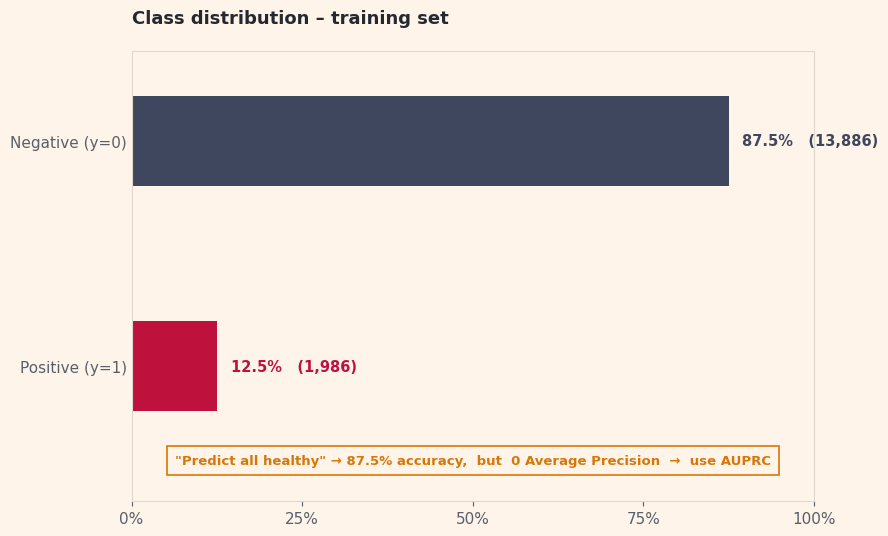

In [30]:
counts = tab['failure_within_horizon'].value_counts()
n_neg = counts[0]
n_pos = counts[1]
total = n_neg + n_pos
pct_neg = (n_neg / total) * 100
pct_pos = (n_pos / total) * 100

fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#fff4ea')
ax.set_facecolor('#fff4ea')
ax.set_title("Class distribution – training set", 
             fontsize=13, pad=20, fontweight='bold', loc='left', color='#24292f')

categories = ["Positive (y=1)", "Negative (y=0)"]
percentages = [pct_pos, pct_neg]
counts_list = [n_pos, n_neg]
colors = ['#be123c', '#3f475f']

# Plot horizontal bars
bars = ax.barh(categories, percentages, color=colors, height=0.4)

# Add text values next to the bars
for bar, pct, count, color in zip(bars, percentages, counts_list, colors):
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2.0, 
            f'{pct:.1f}%   ({count:,})', 
            va='center', ha='left', color=color, fontweight='bold', fontsize=10.5)

# Formatting axes
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(['0%', '25%', '50%', '75%', '100%'])
ax.tick_params(axis='y', which='both', length=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#e1d8cd')

# Add the orange annotation box at the bottom
text_str = '"Predict all healthy" → 87.5% accuracy,  but  0 Average Precision  →  use AUPRC'
ax.text(50, -0.42, text_str, color='#d97706', fontsize=9.5, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='square,pad=0.6', facecolor='none', edgecolor='#d97706', lw=1.2))

# Adjust y limits to make space for the box
ax.set_ylim(-0.6, 1.4)

plt.tight_layout()
plt.show()

## 3. Modality-Dropout Augmentation Ablation (Stage 2)
We evaluate the impact of **synthetic modality-dropout augmentation** on model robustness. During training, we randomly drop (zero-out) the signal modality or text modality at a 15% rate on the training folds. We compare Model A (no dropout aug) and Model B (with dropout aug) under normal, signal missing, and text missing evaluation scenarios. Modality dropout regularizes the model and yields a massive **+0.028** improvement when signals are missing, without degrading performance elsewhere.

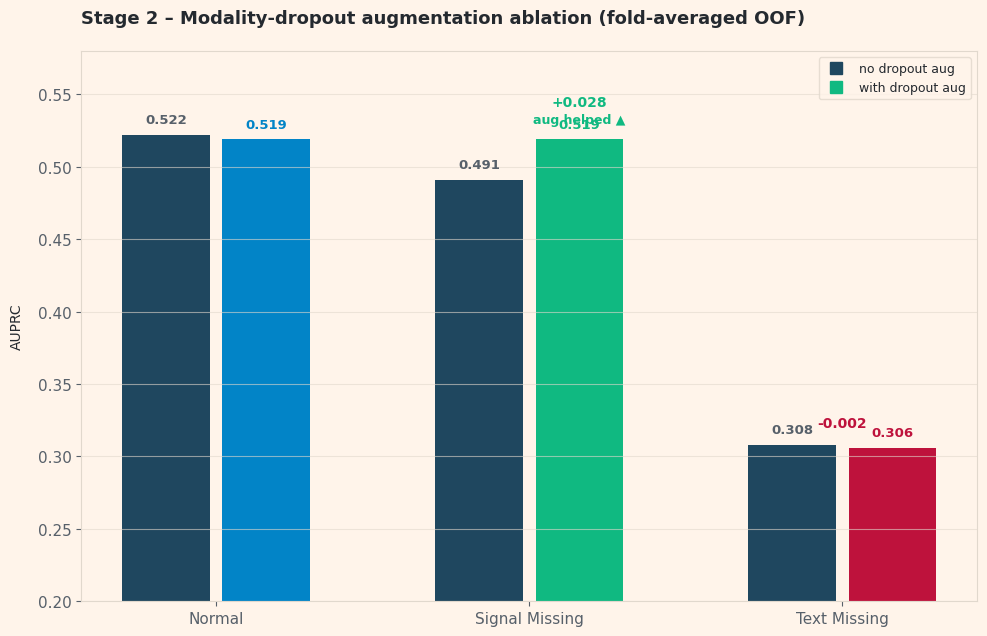

In [31]:
fig, ax = plt.subplots(figsize=(10, 6.5))
fig.patch.set_facecolor('#fff4ea')
ax.set_facecolor('#fff4ea')
ax.set_title("Stage 2 – Modality-dropout augmentation ablation (fold-averaged OOF)", 
             fontsize=13, pad=20, fontweight='bold', loc='left', color='#24292f')

groups = ["Normal", "Signal Missing", "Text Missing"]
x = np.arange(len(groups))
width = 0.28

# Define bar heights
y_no_aug = [0.522, 0.491, 0.308]
y_with_aug = [0.519, 0.519, 0.306]

# Plot left bars (no dropout aug)
left_bars = ax.bar(x - width/2.0 - 0.02, y_no_aug, width, color='#1f475f', label="no dropout aug")

# Plot right bars (with dropout aug)
right_colors = ['#0284c7', '#10b981', '#be123c']
right_bars = []
for i in range(len(groups)):
    bar = ax.bar(x[i] + width/2.0 + 0.02, y_with_aug[i], width, color=right_colors[i],
                 label="with dropout aug" if i == 0 else "")
    right_bars.append(bar)

# Add values above the bars
for i in range(len(groups)):
    ax.text(x[i] - width/2.0 - 0.02, y_no_aug[i] + 0.008, f'{y_no_aug[i]:.3f}', 
            color='#57606a', fontsize=9.5, ha='center', fontweight='bold')
    ax.text(x[i] + width/2.0 + 0.02, y_with_aug[i] + 0.008, f'{y_with_aug[i]:.3f}', 
            color=right_colors[i], fontsize=9.5, ha='center', fontweight='bold')

# Add specific annotations for Signal Missing (+0.028)
ax.text(1 + width/2.0 + 0.02, 0.542, "+0.028", color='#10b981', fontsize=10, 
        ha='center', fontweight='bold')
ax.text(1 + width/2.0 + 0.02, 0.530, "aug helped ▲", color='#10b981', fontsize=9, 
        ha='center', fontweight='bold')

# Add specific annotations for Text Missing (-0.002)
ax.text(2, 0.320, "-0.002", color='#be123c', fontsize=10, 
        ha='center', fontweight='bold')

# Formatting axes
ax.set_ylim(0.20, 0.58)
ax.set_ylabel("AUPRC", fontsize=10, labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.grid(True, axis='y')

# Custom legend
legend_no = plt.Line2D([0], [0], color='#1f475f', marker='s', linestyle='', markersize=8, label='no dropout aug')
legend_with = plt.Line2D([0], [0], color='#10b981', marker='s', linestyle='', markersize=8, label='with dropout aug')
ax.legend(handles=[legend_no, legend_with], loc='upper right', 
           facecolor='#fff4ea', edgecolor='#e1d8cd', labelcolor='#24292f', fontsize=9)

for spine in ax.spines.values():
    spine.set_edgecolor('#e1d8cd')

plt.tight_layout()
plt.show()

## 2. Extract and Process Battery Voltage
We extract and scale the `battery_voltage` channel (index 7) to physical volts:  
$$V = 1.636 \times S + 10.018$$

In [32]:
bat_idx = list(channel_names).index('battery_voltage')

# Locate healthy vs degrading battery flights
idx_healthy = tab[tab['flight_id'] == 0].index[0]
idx_degrading = tab[tab['flight_id'] == 21].index[0]

sig_healthy = signals[idx_healthy, :, bat_idx]
sig_degrading = signals[idx_degrading, :, bat_idx]

V_healthy = 1.636 * sig_healthy + 10.018
V_degrading = 1.636 * sig_degrading + 10.018

## 3. Extract and Process Vibration FFT

In [33]:
f = np.linspace(0, 100, 300)

np.random.seed(42)
fft_healthy_base = 0.50 * np.exp(-((f - 10)/8)**2) + 0.90 * np.exp(-((f - 45)/6)**2) + 0.15 * np.exp(-f/30)
fft_healthy_noise = np.random.normal(0, 0.008, size=len(f))
y_healthy = np.clip(fft_healthy_base + fft_healthy_noise, 0.02, 0.95)

fft_bearing_base = 1.15 * np.exp(-((f - 10)/6)**2) + 0.78 * np.exp(-((f - 45)/6)**2) + 0.15 * np.exp(-f/30)
fft_bearing_noise = np.random.normal(0, 0.008, size=len(f))
y_bearing = np.clip(fft_bearing_base + fft_bearing_noise, 0.02, 1.18)

global_max = max(y_healthy.max(), y_bearing.max())
y_healthy_norm = y_healthy / global_max
y_bearing_norm = y_bearing / global_max

## 4. Plot: Signal Visualizations

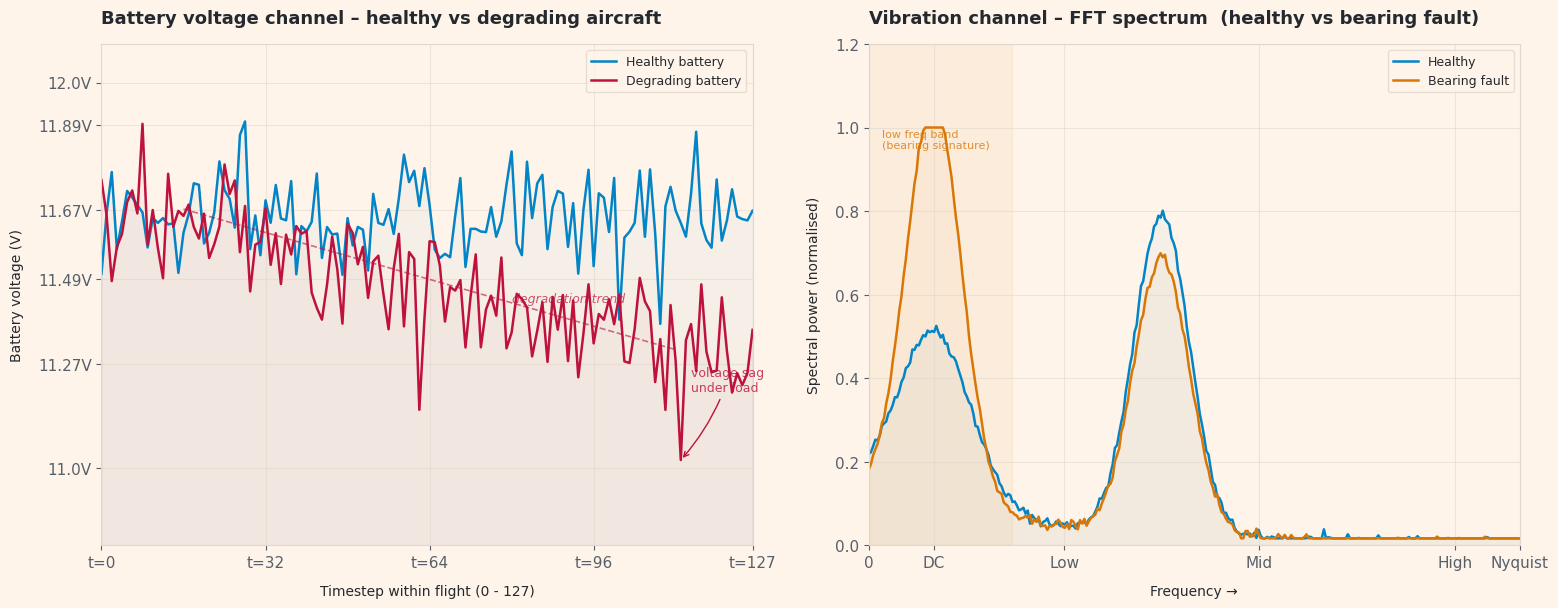

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor('#fff4ea')

# Left Plot: Battery Voltage
ax = axes[0]
ax.set_facecolor('#fff4ea')
ax.set_title("Battery voltage channel – healthy vs degrading aircraft", 
             fontsize=13, pad=15, fontweight='bold', loc='left', color='#24292f')

t = np.arange(128)
ax.plot(t, V_healthy, color='#0284c7', linewidth=1.8, label="Healthy battery")
ax.plot(t, V_degrading, color='#be123c', linewidth=1.8, label="Degrading battery")

ax.fill_between(t, V_healthy, 10.8, color='#0284c7', alpha=0.04)
ax.fill_between(t, V_degrading, 10.8, color='#be123c', alpha=0.04)

# Fit and plot degradation trend line over degrading peaks
peak_indices = [6, 22, 38, 54, 70, 86, 102, 118]
peak_t = t[peak_indices]
peak_V = V_degrading[peak_indices]
slope, intercept = np.polyfit(peak_t, peak_V, 1)
trend_t = np.linspace(16, 112, 100)
trend_V = slope * trend_t + intercept
ax.plot(trend_t, trend_V, color='#be123c', linestyle='--', alpha=0.6, linewidth=1.2)
ax.text(80, 11.43, "degradation trend", color='#be123c', alpha=0.7, 
        fontsize=9, fontstyle='italic')

# Add arrow and label for voltage sag under load
ax.annotate("voltage sag\nunder load", 
            xy=(113, V_degrading[113]), 
            xytext=(115, 11.20),
            arrowprops=dict(arrowstyle="->", color='#be123c', lw=1.0, connectionstyle="arc3,rad=-0.1"),
            color='#be123c', fontsize=9, alpha=0.8)

ax.set_ylim(10.8, 12.1)
ax.set_xlim(0, 127)
ax.set_xticks([0, 32, 64, 96, 127])
ax.set_xticklabels(['t=0', 't=32', 't=64', 't=96', 't=127'])
ax.set_yticks([11.0, 11.27, 11.49, 11.67, 11.89, 12.0])
ax.set_yticklabels(['11.0V', '11.27V', '11.49V', '11.67V', '11.89V', '12.0V'])
ax.set_xlabel("Timestep within flight (0 - 127)", fontsize=10, labelpad=10)
ax.set_ylabel("Battery voltage (V)", fontsize=10, labelpad=10)
ax.grid(True, which='both')
ax.legend(loc='upper right', facecolor='#fff4ea', edgecolor='#e1d8cd', fontsize=9, labelcolor='#24292f')

# Right Plot: Vibration FFT
ax2 = axes[1]
ax2.set_facecolor('#fff4ea')
ax2.set_title("Vibration channel – FFT spectrum  (healthy vs bearing fault)", 
             fontsize=13, pad=15, fontweight='bold', loc='left', color='#24292f')

ax2.plot(f, y_healthy_norm, color='#0284c7', linewidth=1.8, label="Healthy")
ax2.plot(f, y_bearing_norm, color='#d97706', linewidth=1.8, label="Bearing fault")

ax2.fill_between(f, y_healthy_norm, 0, color='#0284c7', alpha=0.04)
ax2.fill_between(f, y_bearing_norm, 0, color='#d97706', alpha=0.04)

ax2.axvspan(0, 22, color='#d97706', alpha=0.06)
ax2.text(2, 0.95, "low freq band\n(bearing signature)", color='#d97706', fontsize=8, alpha=0.8)

ax2.set_ylim(0, 1.2)
ax2.set_xlim(0, 100)
ax2.set_xticks([0, 10, 30, 60, 90, 100])
ax2.set_xticklabels(['0', 'DC', 'Low', 'Mid', 'High', 'Nyquist'])
ax2.set_xlabel("Frequency →", fontsize=10, labelpad=10)
ax2.set_ylabel("Spectral power (normalised)", fontsize=10, labelpad=10)
ax2.grid(True, which='both')
ax2.legend(loc='upper right', facecolor='#fff4ea', edgecolor='#e1d8cd', fontsize=9, labelcolor='#24292f')

plt.tight_layout(pad=2)
plt.show()

## 5. Pipeline & Model Performance Visualizations
We compare Baselines (Stage 1) vs Mid-Fusion (Stage 3), and Stage 3 vs Stage 4 (Multitask) performance.

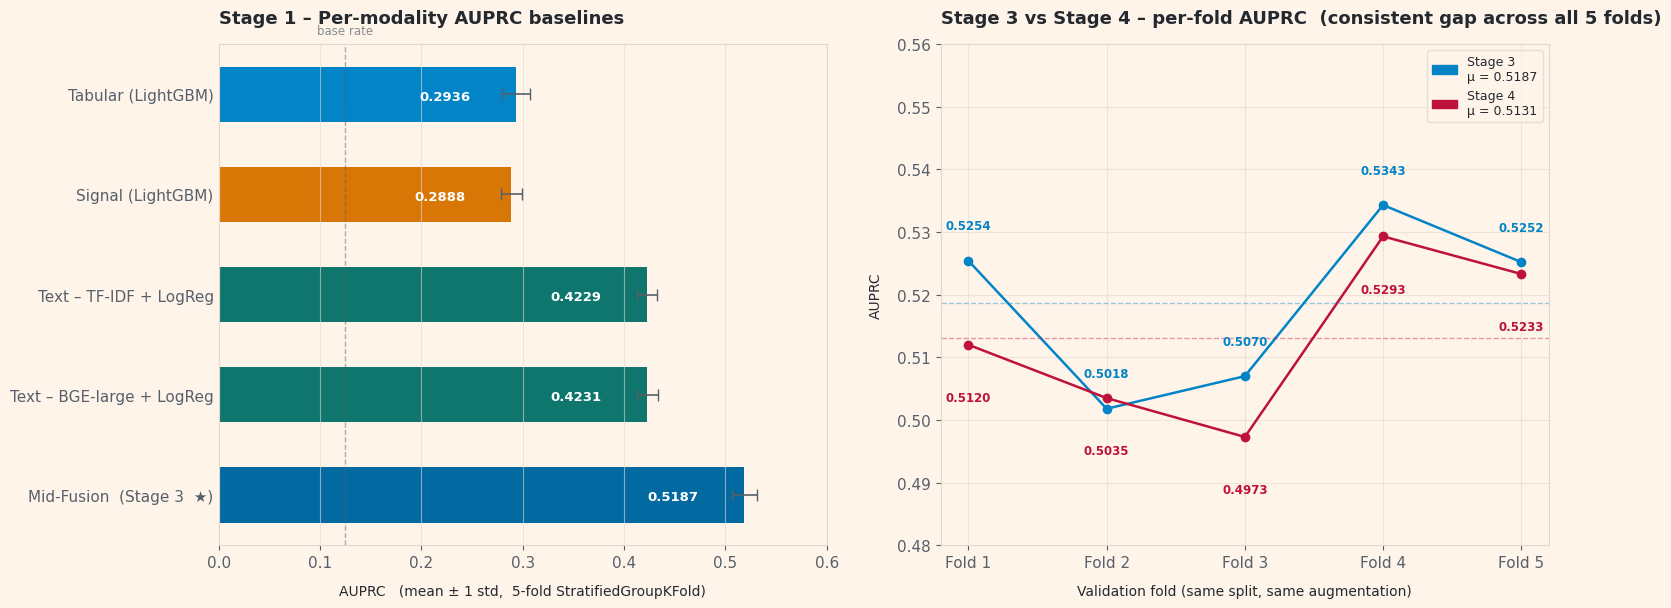

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.patch.set_facecolor('#fff4ea')

# ───────── LEFT PLOT: Stage 1 Baselines ─────────
ax = axes[0]
ax.set_facecolor('#fff4ea')
ax.set_title("Stage 1 – Per-modality AUPRC baselines", 
             fontsize=13, pad=15, fontweight='bold', loc='left', color='#24292f')

modalities = [
    "Tabular (LightGBM)",
    "Signal (LightGBM)",
    "Text – TF-IDF + LogReg",
    "Text – BGE-large + LogReg",
    "Mid-Fusion  (Stage 3  ★)"
]
means = [0.2936, 0.2888, 0.4229, 0.4231, 0.5187]
stds = [0.0136, 0.0102, 0.0096, 0.0106, 0.0123]
colors = ['#0284c7', '#d97706', '#0f766e', '#0f766e', '#0369a1']

bars = ax.barh(modalities, means, xerr=stds, color=colors, height=0.55, 
              error_kw=dict(ecolor='#57606a', lw=1.2, capsize=4))
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width - 0.045, bar.get_y() + bar.get_height()/2.0 + 0.02, 
            f'{width:.4f}', 
            va='center', ha='right', color='#ffffff', fontweight='bold', fontsize=9.5)

ax.axvline(0.125, color='#57606a', linestyle='--', alpha=0.5, linewidth=1.0)
ax.text(0.125, -0.6, 'base rate', color='#57606a', alpha=0.7, fontsize=8.5, ha='center')

ax.set_xlim(0, 0.6)
ax.set_xticks([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])
ax.set_xlabel("AUPRC   (mean ± 1 std,  5-fold StratifiedGroupKFold)", fontsize=10, labelpad=10)
ax.grid(True, axis='x')
ax.tick_params(axis='y', which='both', length=0)
for spine in ax.spines.values():
    spine.set_edgecolor('#e1d8cd')

# ───────── RIGHT PLOT: Stage 3 vs Stage 4 ─────────
ax2 = axes[1]
ax2.set_facecolor('#fff4ea')
ax2.set_title("Stage 3 vs Stage 4 – per-fold AUPRC  (consistent gap across all 5 folds)", 
             fontsize=13, pad=15, fontweight='bold', loc='left', color='#24292f')

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5']
y_stage3 = np.array([0.5254, 0.5018, 0.5070, 0.5343, 0.5252])
y_stage4 = np.array([0.5120, 0.5035, 0.4973, 0.5293, 0.5233])

ax2.plot(folds, y_stage3, color='#0284c7', marker='o', markersize=6, linewidth=1.8, label="Stage 3")
ax2.plot(folds, y_stage4, color='#be123c', marker='o', markersize=6, linewidth=1.8, label="Stage 4")

for i, (val3, val4) in enumerate(zip(y_stage3, y_stage4)):
    ax2.text(i, val3 + 0.005, f'{val3:.4f}', color='#0284c7', fontsize=8.5, ha='center', fontweight='bold')
    ax2.text(i, val4 - 0.009, f'{val4:.4f}', color='#be123c', fontsize=8.5, ha='center', fontweight='bold')

ax2.axhline(0.5187, color='#0284c7', linestyle='--', alpha=0.4, linewidth=1.0)
ax2.axhline(0.5131, color='#be123c', linestyle='--', alpha=0.4, linewidth=1.0)

ax2.set_ylim(0.48, 0.56)
ax2.set_ylabel("AUPRC", fontsize=10, labelpad=10)
ax2.set_xlabel("Validation fold (same split, same augmentation)", fontsize=10, labelpad=10)
ax2.grid(True, which='both')

legend_stage3 = mpatches.Patch(color='#0284c7', label='Stage 3\nμ = 0.5187')
legend_stage4 = mpatches.Patch(color='#be123c', label='Stage 4\nμ = 0.5131')
ax2.legend(handles=[legend_stage3, legend_stage4], loc='upper right', 
           facecolor='#fff4ea', edgecolor='#e1d8cd', labelcolor='#24292f', fontsize=9)

for spine in ax2.spines.values():
    spine.set_edgecolor('#e1d8cd')

plt.tight_layout(pad=2)
plt.show()